# Ch3 調機(Tuning a Control System)

**對應原書**:Chapter 3(zone-based tuning)
**軟體替代**:ModelQ 的 Live Constant 滑桿 → 參數掃描 + 自動化指標表

## 學習目標
1. 實作 Ellis 的**分區調機法(zone-based tuning)**:先調 P、後調 I。
2. 理解「增益↑ → 響應快但邊限↓」的基本取捨。
3. 學會用 overshoot 作為現場調機的代理指標。

## 分區調機程序(速度迴路版)
1. 令 `ki=0`,將 `kp` 由小往上調,直到階躍響應出現約 **4~5% overshoot**。
2. 固定 `kp`,將 `ki` 往上調,直到 overshoot 約 **15%**。
3. 完成。此法在數位迴路(含取樣延遲)特別實用,因為延遲讓過高的 `kp` 立刻以振鈴顯形。

實驗平台:1 kHz 離散速度迴路(含一拍計算延遲),受控體同第 2 章($J=0.002$, $b=0.01$)。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

In [2]:
J, b = 0.002, 0.01
fs = 1000.0
dt = 1 / fs

def run_step(kp, ki, t_end=0.4):
    plant = MotorPlant(J=J, b=b, dt=dt)
    ctrl = DiscretePID(kp=kp, ki=ki, dt=dt)
    dly = Delay(1)                       # 一拍計算延遲(貼近實機)
    n = int(t_end / dt)
    y = np.empty(n)
    for k in range(n):
        y[k] = plant.w
        plant.step(dly.step(ctrl.step(1.0 - plant.w)))
    t = np.arange(n) * dt
    return t, y

# --- 步驟 1:ki=0,掃 kp ---
kps = np.round(np.arange(0.1, 2.01, 0.1), 2)
os_p = []
for kp in kps:
    t, y = run_step(kp, 0.0)
    os_p.append(step_metrics(t, y)['overshoot_pct'])
kp_sel = float(kps[np.nonzero(np.array(os_p) >= 4.0)[0][0]])
print('kp sweep overshoot%:', dict(zip(kps.tolist(), np.round(os_p, 1).tolist())))
print(f'選定 kp = {kp_sel}(overshoot 首次 ≥ 4%)')

kp sweep overshoot%: {0.1: 0.0, 0.2: 0.0, 0.3: 0.0, 0.4: 0.0, 0.5: 0.0, 0.6: 0.0, 0.7: 4.5, 0.8: 11.0, 0.9: 18.1, 1.0: 24.3, 1.1: 33.9, 1.2: 43.1, 1.3: 51.8, 1.4: 60.0, 1.5: 67.6, 1.6: 74.8, 1.7: 81.5, 1.8: 87.7, 1.9: 93.3, 2.0: 114.5}
選定 kp = 0.7(overshoot 首次 ≥ 4%)


ki sweep overshoot%: {0: 4.5, 5: 6.3, 10: 8.1, 15: 9.9, 20: 11.7, 25: 13.5, 30: 15.5, 35: 17.6, 40: 19.6, 45: 21.6, 50: 23.6, 55: 25.7, 60: 27.7, 65: 29.7, 70: 31.6, 75: 33.6, 80: 35.6}
選定 ki = 30.0(overshoot 首次 ≥ 15%)


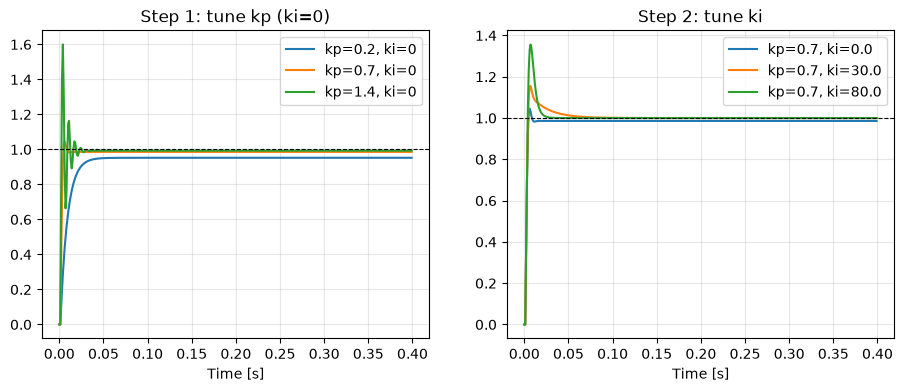

In [3]:
# --- 步驟 2:固定 kp,掃 ki ---
kis = np.arange(0, 81, 5)
os_i = []
for ki in kis:
    t, y = run_step(kp_sel, float(ki))
    os_i.append(step_metrics(t, y)['overshoot_pct'])
ki_sel = float(kis[np.nonzero(np.array(os_i) >= 15.0)[0][0]])
print('ki sweep overshoot%:', dict(zip(kis.tolist(), np.round(os_i, 1).tolist())))
print(f'選定 ki = {ki_sel}(overshoot 首次 ≥ 15%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for kp in [0.2, kp_sel, 1.4]:
    t, y = run_step(kp, 0.0)
    ax1.plot(t, y, label=f'kp={kp}, ki=0')
for ki in [0.0, ki_sel, 80.0]:
    t, y = run_step(kp_sel, ki)
    ax2.plot(t, y, label=f'kp={kp_sel}, ki={ki}')
for ax in (ax1, ax2):
    ax.axhline(1, color='k', ls='--', lw=0.8); ax.grid(alpha=0.3)
    ax.set_xlabel('Time [s]'); ax.legend()
ax1.set_title('Step 1: tune kp (ki=0)'); ax2.set_title('Step 2: tune ki')
plt.show()

## 用頻域檢查調機結果

調完後務必回頭看邊限。離散迴路的等效延遲 ≈ 1.5 個取樣週期
(ZOH 半拍 + 計算/更新一拍),對應相位損失 $360° \cdot f_c \cdot 1.5T_s$。

In [4]:
C_sel = pi(kp=kp_sel, ki=ki_sel)
P = inertia(J=J, b=b)
m_analog = margins(C_sel * P)
phase_loss = 360.0 * m_analog['f_pm_hz'] * 1.5 * dt
pm_digital = m_analog['pm_deg'] - phase_loss
print(f"類比 PM = {m_analog['pm_deg']:.1f}° @ {m_analog['f_pm_hz']:.1f} Hz")
print(f"取樣延遲相位損失 ≈ {phase_loss:.1f}° → 數位 PM ≈ {pm_digital:.1f}°")

t, y = run_step(kp_sel, ki_sel)
mets = step_metrics(t, y)
print('最終調機結果:', {k: round(v, 4) for k, v in mets.items()})

類比 PM = 83.9° @ 56.1 Hz
取樣延遲相位損失 ≈ 30.3° → 數位 PM ≈ 53.6°
最終調機結果: {'rise_time': 0.002, 'overshoot_pct': 15.5405, 'settling_time': 0.042, 'steady_state_error': -0.0}


In [5]:
# ✅ 驗證
assert np.all(np.diff(os_p) > -0.5), 'overshoot 應隨 kp 大致遞增'
assert 4 <= os_p[list(kps).index(kp_sel)] < 30
assert 14 <= mets['overshoot_pct'] < 30      # 步驟 2 目標 ~15%
assert 30 < pm_digital < 75                  # 合理的數位 PM
assert abs(mets['steady_state_error']) < 0.01
print('Ch3 驗證通過 ✅')

Ch3 驗證通過 ✅


## 練習
1. 把取樣率降到 500 Hz 重跑整個調機流程,選出的 kp 有何不同?為什麼?
2. 改用 overshoot 目標 2%/10% 重調,比較頻寬與 PM。
3. 在受控體加入 20% 的慣量誤差,原調機參數的 overshoot 變化多少?
4. 寫一個函式自動執行完整 zone-based tuning,回傳 (kp, ki, 指標表)。